In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    explained_variance_score
)

In [4]:
df = pd.read_csv("../Data/housing.csv")

In [5]:
import pandas as pd

df = pd.read_csv("../Data/housing.csv")

print(df.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


In [8]:
df = pd.read_csv("../Data/housing.csv")

In [9]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [11]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [12]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [13]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(
    df["total_bedrooms"].median()
)

In [14]:
df = pd.get_dummies(
    df,
    columns=["ocean_proximity"],
    drop_first=True
)

task 1 - build baseline linear regression model


In [15]:
y = df["median_house_value"]

In [16]:
X = df.drop("median_house_value", axis=1)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [18]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](12,)","[-26838.27,-25468.35, 1102.19,...,136125.07, -5136.64, 3431.14]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](12,)","['longitude','latitude','housing_median_age',...,'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY','ocean_proximity_NEAR OCEAN']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.276e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,12
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,12


In [19]:
y_pred = model.predict(X_test)

In [20]:
mse = mean_squared_error(y_test, y_pred)

In [21]:
rmse = np.sqrt(mse)

In [22]:
mae = mean_absolute_error(y_test, y_pred)

In [23]:
r2 = r2_score(y_test, y_pred)

In [24]:
print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

MSE : 4908476721.156625
RMSE: 70060.52184473525
MAE : 50670.7382409721
R2  : 0.6254240620553599


In [25]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,47700.0,54055.448899
1,45800.0,124225.338937
2,500001.0,255489.379492
3,218600.0,268002.431569
4,278000.0,262769.434816
5,158700.0,139606.303956
6,198200.0,290665.423914
7,157500.0,228264.876375
8,340000.0,256506.785610
9,446600.0,407923.858435


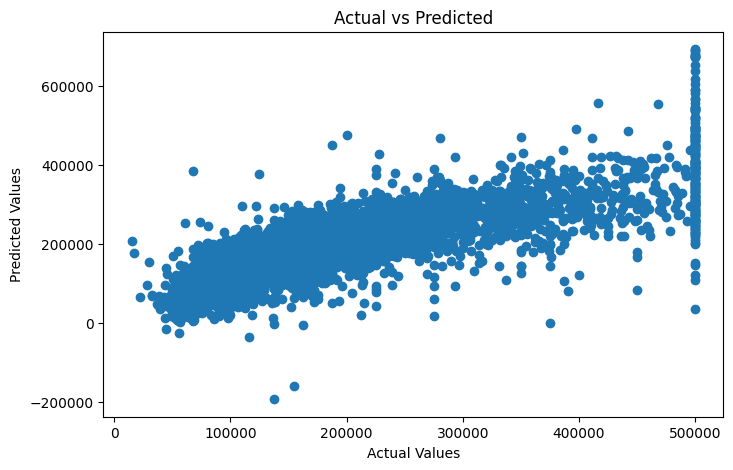

In [26]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted")

plt.show()

TASK 2 - Compare One Feature vs Multiple Features

In [27]:
X1 = df[["median_income"]]

y = df["median_house_value"]

In [28]:
X1_train, X1_test, y_train, y_test = train_test_split(
    X1,
    y,
    test_size=0.20,
    random_state=42
)

In [29]:
model_a = LinearRegression()

model_a.fit(X1_train, y_train)

pred_a = model_a.predict(X1_test)

In [30]:
mse_a = mean_squared_error(y_test, pred_a)
rmse_a = np.sqrt(mse_a)
mae_a = mean_absolute_error(y_test, pred_a)
r2_a = r2_score(y_test, pred_a)

In [31]:
features = [
    "median_income",
    "housing_median_age",
    "total_rooms",
    "population"
]

X2 = df[features]

In [32]:
features = [
    "median_income",
    "housing_median_age",
    "total_rooms",
    "population"
]

X2 = df[features]

In [33]:
X2_train, X2_test, y_train, y_test = train_test_split(
    X2,
    y,
    test_size=0.20,
    random_state=42
)

In [34]:
model_b = LinearRegression()

model_b.fit(X2_train, y_train)

pred_b = model_b.predict(X2_test)

In [35]:
mse_b = mean_squared_error(y_test, pred_b)
rmse_b = np.sqrt(mse_b)
mae_b = mean_absolute_error(y_test, pred_b)
r2_b = r2_score(y_test, pred_b)

In [36]:
results = pd.DataFrame({
    "Metric":["MSE","RMSE","MAE","R2"],
    "Model A":[mse_a, rmse_a, mae_a, r2_a],
    "Model B":[mse_b, rmse_b, mae_b, r2_b]
})

results

,Metric,Model A,Model B
0,MSE,7.091158e+09,6.535242e+09
1,RMSE,8.420901e+04,8.084084e+04
2,MAE,6.299087e+04,6.048399e+04
3,R2,4.588592e-01,5.012823e-01


Model B performed better because it uses multiple
features and achieved lower MSE, RMSE, MAE and
higher R² score than Model A.


TASK 3- Different Train/Test Splits

In [37]:
features = [
    "median_income",
    "housing_median_age",
    "total_rooms",
    "population"
]

X = df[features]

y = df["median_house_value"]

In [38]:
test_size = 0.20

In [39]:
test_size = 0.30

In [40]:
test_size = 0.40

In [41]:
splits = [0.20,0.30,0.40]

records = []

for split in splits:

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=split,
        random_state=42
    )

    model = LinearRegression()

    model.fit(X_train,y_train)

    train_pred = model.predict(X_train)

    test_pred = model.predict(X_test)

    train_mse = mean_squared_error(y_train,train_pred)
    test_mse = mean_squared_error(y_test,test_pred)

    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)

    train_mae = mean_absolute_error(y_train,train_pred)
    test_mae = mean_absolute_error(y_test,test_pred)

    train_r2 = r2_score(y_train,train_pred)
    test_r2 = r2_score(y_test,test_pred)

    records.append([
        f"{int((1-split)*100)}/{int(split*100)}",
        train_mse,
        test_mse,
        train_rmse,
        test_rmse,
        train_mae,
        test_mae,
        train_r2,
        test_r2
    ])

In [42]:
split_results = pd.DataFrame(
    records,
    columns=[
        "Split",
        "Train MSE",
        "Test MSE",
        "Train RMSE",
        "Test RMSE",
        "Train MAE",
        "Test MAE",
        "Train R2",
        "Test R2"
    ]
)

split_results

,Split,Train MSE,Test MSE,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2
0,80/20,6.408802e+09,6.535242e+09,80054.990538,80840.842129,59956.069822,60483.993513,0.520579,0.501282
1,70/30,6.461012e+09,6.372229e+09,80380.417450,79826.244050,60150.574760,59908.903850,0.517726,0.514512
2,60/40,6.391387e+09,6.498553e+09,79946.148970,80613.605372,59775.512891,60384.556160,0.518254,0.514564


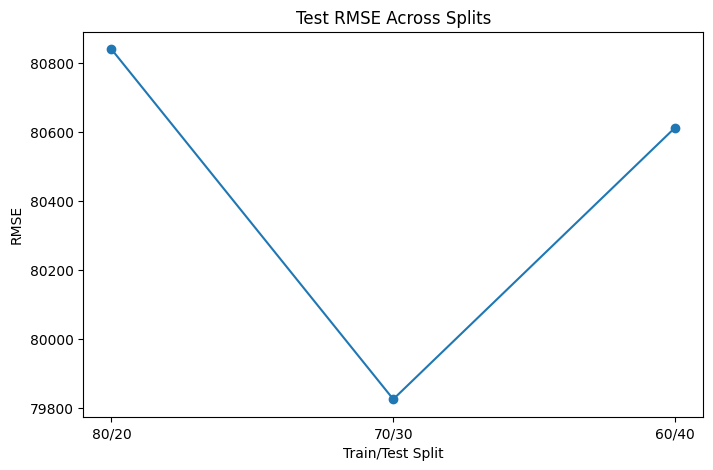

In [43]:
plt.figure(figsize=(8,5))

plt.plot(
    split_results["Split"],
    split_results["Test RMSE"],
    marker="o"
)

plt.title("Test RMSE Across Splits")

plt.xlabel("Train/Test Split")
plt.ylabel("RMSE")

plt.show()

The split with the highest test R² and lowest
test RMSE is considered the most reliable.

TASK 4 - Metric Verification & Exploration

In [44]:
manual_mse = np.mean(
    (y_test - test_pred) ** 2
)

In [45]:
manual_rmse = np.sqrt(manual_mse)

In [46]:
manual_mae = np.mean(
    np.abs(y_test - test_pred)
)

In [47]:
ss_res = np.sum(
    (y_test - test_pred)**2
)

ss_tot = np.sum(
    (y_test - np.mean(y_test))**2
)

manual_r2 = 1 - (ss_res/ss_tot)

In [48]:
comparison = pd.DataFrame({
    "Metric":["MSE","RMSE","MAE","R2"],
    "Manual":[
        manual_mse,
        manual_rmse,
        manual_mae,
        manual_r2
    ],
    "Sklearn":[
        mean_squared_error(y_test,test_pred),
        np.sqrt(mean_squared_error(y_test,test_pred)),
        mean_absolute_error(y_test,test_pred),
        r2_score(y_test,test_pred)
    ]
})

comparison

,Metric,Manual,Sklearn
0,MSE,6.498553e+09,6.498553e+09
1,RMSE,8.061361e+04,8.061361e+04
2,MAE,6.038456e+04,6.038456e+04
3,R2,5.145642e-01,5.145642e-01


In [49]:
evs = explained_variance_score(
    y_test,
    test_pred
)

print(evs)

0.5146192288589707


In [50]:
final_metrics = pd.DataFrame({
    "Metric":[
        "MSE",
        "RMSE",
        "MAE",
        "R2",
        "Explained Variance"
    ],
    "Value":[
        manual_mse,
        manual_rmse,
        manual_mae,
        manual_r2,
        evs
    ]
})

final_metrics

,Metric,Value
0,MSE,6.498553e+09
1,RMSE,8.061361e+04
2,MAE,6.038456e+04
3,R2,5.145642e-01
4,Explained Variance,5.146192e-01


In [51]:
error_pred = test_pred.copy()

error_pred[0] += 500000
error_pred[1] += 500000
error_pred[2] += 500000

In [52]:
new_mse = mean_squared_error(
    y_test,
    error_pred
)

new_rmse = np.sqrt(new_mse)

new_mae = mean_absolute_error(
    y_test,
    error_pred
)

print(new_mse)
print(new_rmse)
print(new_mae)

6578409670.025493
81107.39590213394
60505.490180059736


MSE increased the most because it squares errors.

RMSE also increased significantly because it is
derived from MSE.

MAE increased but less dramatically because it
uses absolute errors instead of squared errors.

Therefore MSE and RMSE are more sensitive to
large prediction errors than MAE.